# LeetCode #132: Palindrome Partitioning II

https://leetcode.com/problems/palindrome-partitioning-ii/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Backtracking + count minimum | O(n·2^n) | O(n) | TLE for large inputs |
| **DP (precompute isPal + min cuts)** | **O(n²)** | **O(n²)** | **Optimal — polynomial time** |

## Understanding the Method

Two-phase DP:
1. **Precompute** `isPal[i][j]` for all substrings — O(n²) time and space
2. **Compute min cuts**: `dp[i]` = minimum cuts for `s[0..i]`
   - If `s[0..i]` is a palindrome → `dp[i] = 0`
   - Otherwise → `dp[i] = min(dp[j-1] + 1)` for all j where `s[j..i]` is a palindrome

## Constraints

- `1 <= s.length <= 2000`
- `s` consists of lowercase English letters.

## Solutions

### C#

In [ ]:
public class Solution {
    public int MinCut(string s) {
        int n = s.Length;
        bool[,] isPal = new bool[n, n];
        for (int i = n-1; i >= 0; i--)
            for (int j = i; j < n; j++)
                isPal[i,j] = s[i] == s[j] && (j - i <= 2 || isPal[i+1,j-1]);
        int[] dp = new int[n];
        for (int i = 0; i < n; i++) {
            if (isPal[0, i]) { dp[i] = 0; continue; }
            dp[i] = i; // max cuts
            for (int j = 1; j <= i; j++)
                if (isPal[j, i]) dp[i] = Math.Min(dp[i], dp[j-1] + 1);
        }
        return dp[n-1];
    }
}

### Python

In [ ]:
class Solution:
    def minCut(self, s: str) -> int:
        n = len(s)
        is_pal = [[False]*n for _ in range(n)]
        for i in range(n-1, -1, -1):
            for j in range(i, n):
                is_pal[i][j] = s[i] == s[j] and (j - i <= 2 or is_pal[i+1][j-1])
        dp = list(range(n))
        for i in range(n):
            if is_pal[0][i]:
                dp[i] = 0
                continue
            for j in range(1, i+1):
                if is_pal[j][i]:
                    dp[i] = min(dp[i], dp[j-1] + 1)
        return dp[n-1]

### Go

In [ ]:
func minCut(s string) int {
    n := len(s)
    isPal := make([][]bool, n)
    for i := range isPal { isPal[i] = make([]bool, n) }
    for i := n - 1; i >= 0; i-- {
        for j := i; j < n; j++ {
            isPal[i][j] = s[i] == s[j] && (j-i <= 2 || isPal[i+1][j-1])
        }
    }
    dp := make([]int, n)
    for i := 0; i < n; i++ { dp[i] = i }
    for i := 0; i < n; i++ {
        if isPal[0][i] { dp[i] = 0; continue }
        for j := 1; j <= i; j++ {
            if isPal[j][i] && dp[j-1]+1 < dp[i] { dp[i] = dp[j-1] + 1 }
        }
    }
    return dp[n-1]
}

### Rust

In [ ]:
impl Solution {
    pub fn min_cut(s: String) -> i32 {
        let s: Vec<u8> = s.bytes().collect();
        let n = s.len();
        let mut is_pal = vec![vec![false; n]; n];
        for i in (0..n).rev() {
            for j in i..n {
                is_pal[i][j] = s[i] == s[j] && (j - i <= 2 || is_pal[i+1][j-1]);
            }
        }
        let mut dp: Vec<i32> = (0..n as i32).collect();
        for i in 0..n {
            if is_pal[0][i] { dp[i] = 0; continue; }
            for j in 1..=i {
                if is_pal[j][i] { dp[i] = dp[i].min(dp[j-1] + 1); }
            }
        }
        dp[n-1]
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `s = "aab"`  
Build isPal table: $\text{isPal}[0][1] = $ "aa" $\checkmark$. Then dp: $dp[0]=0$ ("a" is palindrome), $dp[1]=0$ ("aa" is palindrome), $dp[2]=1$ since "aab" is not a palindrome but "aa"|"b" gives $dp[1]+1 = 1$.  
WHY tricky: Validates that when the whole prefix is a palindrome, $dp[i] = 0$, and when it's not, we try all palindromic suffix split points.  
$\text{min cut} = 1$: "aa" | "b"  
**Output:** `1`

### 2. Slightly Complex
**Input:** `s = "cababd"`  
Palindromic substrings include "aba" (indices 1-3) and "bab" (indices 2-4). The DP discovers: $dp[3] = 1$ via "c"|"aba", $dp[4] = 2$ via "c"|"aba"|"b" or "ca"|"bab". Final: $dp[5] = 3$.  
WHY tricky: Multiple overlapping palindromes offer different split points. The DP must try all palindromic suffixes at each position to find the global minimum.  
**Output:** `3` (e.g., "c" | "aba" | "b" | "d")

### 3. Edge Case: Time Factor
**Input:** `s = "aaa...a"` (2000 a's — max constraint)  
The entire string is one palindrome, so $dp[1999] = 0$. But isPal precomputation still fills a $2000 \times 2000$ table: $O(n^2) = 4{,}000{,}000$ entries.  
WHY tricky: $n = 2000$ means $O(n^2) = 4 \times 10^6$ operations. Tests that the solution is polynomial, not exponential like the backtracking from #131.  
**Output:** `0` (entire string is a palindrome)

### 4. Edge Case: Space Factor
**Input:** `s` of length 2000 with all distinct characters  
The isPal table uses $n^2 = 4{,}000{,}000$ booleans ($\sim4$ MB). The dp array is only $O(n) = 2000$ ints. No multi-character palindromes exist, so every $dp[i] = i$ (max cuts).  
WHY tricky: $O(n^2)$ isPal table dominates space at $\sim4$ MB. Can be reduced to $O(n)$ with expand-around-center palindrome detection integrated into the DP.  
**Output:** `1999` (every character must be separated)

### 5. Almost-Impossible but Plausible
**Input:** `s = "aaa...a" + "b" + "aaa...a"` (999 a's + 'b' + 1000 a's, length 2000)  
The lone 'b' at position 999 forces at least one cut. Optimal: "aaa...a" | "b" | "aaa...a" $= 2$ cuts. The DP discovers $\text{isPal}[0][998] = \text{true}$ and $\text{isPal}[1000][1999] = \text{true}$.  
WHY tricky: A single different character in 2000 chars changes minimum from 0 to 2. Tests whether DP finds the optimal split around a single anomaly.  
**Output:** `2`

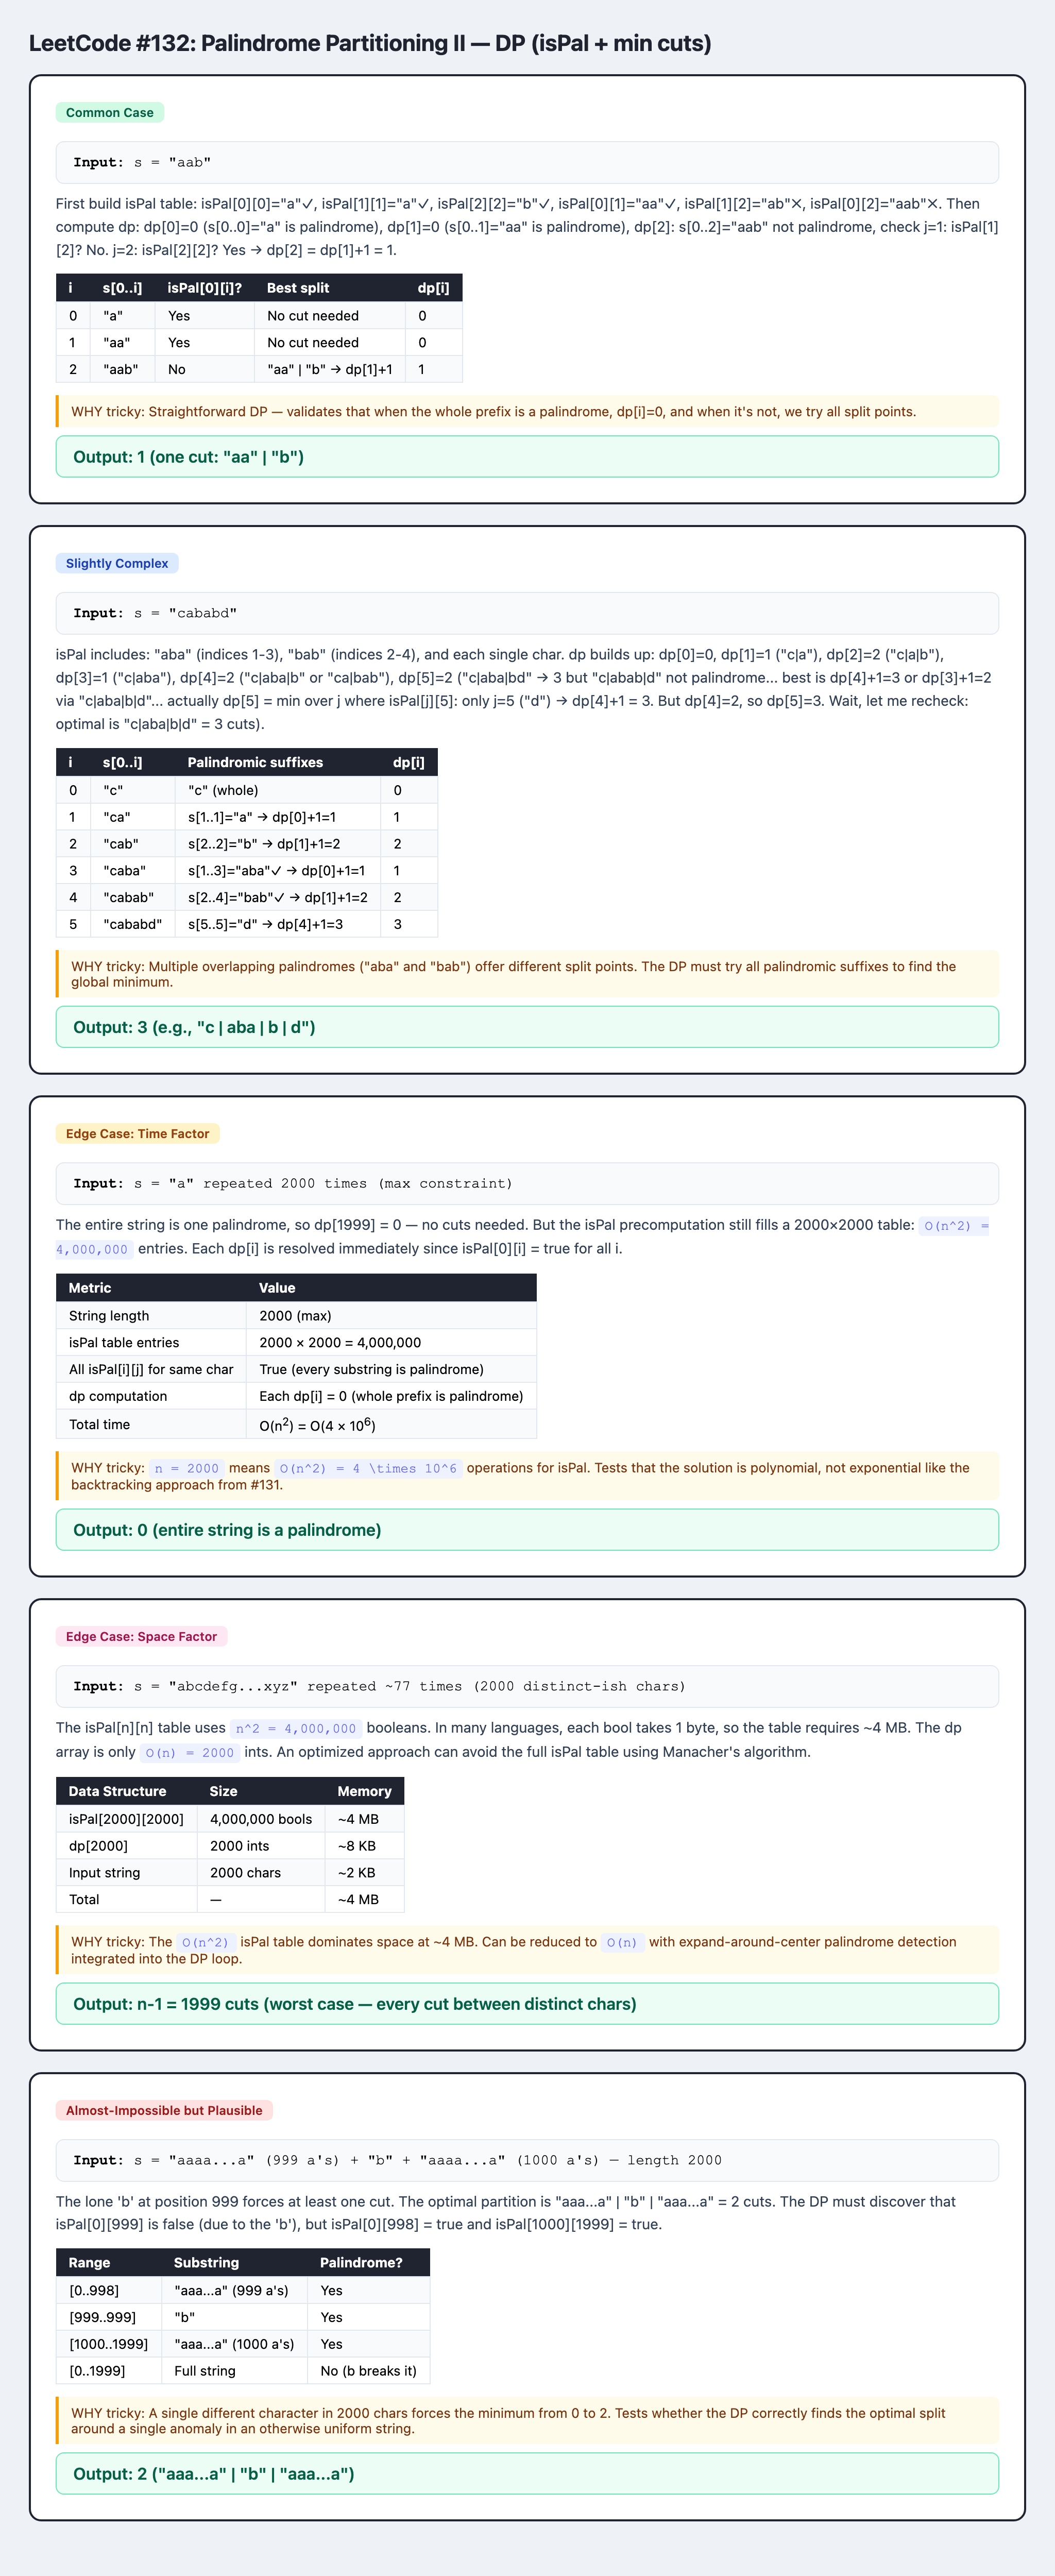